In [ ]:
import argparse
import sys
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging
import os
import pandas as pd
import re
from sklearn.metrics import auc
import scanpy as sc
import glob
import anndata as ad
from matplotlib.colors import ListedColormap
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 200

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, Future

In [ ]:
dist_dir = '../data/validations/dist_to_edge/'

sample_list = glob.glob(dist_dir+"*edge_dists.csv")

# samples to exclude based on poor ability to estimate periphery
# often due to dying/split orgs
skip = [
    '../data/validations/dist_to_edge/AT410-BRA-5-ORG-e25-MOI0_25-D7-S43-C1_GSO2_edge_dists.csv',
    '../data/validations/dist_to_edge/AT410-BRA-5-ORG-E30-MOI0_25-D7-S38-B2_GSO2_edge_dists.csv',
    '../data/validations/dist_to_edge/AT410-BRA-5-ORG-E30-MOI0_25-D7-S8-A1_GSO2_edge_dists.csv'
]

distance_df = []
for sample in sample_list:
    if sample not in skip:
        distance_df.append(pd.read_csv(sample, index_col=0))
distance_df = pd.concat(distance_df)

malignant_cts = [
 'AC-gliosis-like',
 'AC-progenitor-like',
 'Gliosis-like',
 'Hypoxic',
 'NPC-neuronal-like',
 'OPC-NPC-like',
 'OPC-like',
 'OPC-neuronal-like',
 'Proliferative'
]

malignant_cts.reverse()

color_palette = {
    "Gliosis-like": "#cd853f",
    "AC-gliosis-like": "#a0522d",
    "Hypoxic": "#bc8f8f",
    "AC-progenitor-like": "#8b4513",
    
    "NPC-neuronal-like": "#c0bdbd",
    
    "OPC-like": "#c0d860",
    "OPC-NPC-like": "#9ec85e",
    "OPC-neuronal-like": "#acd748",
    
    "Proliferative": "#35aee3",
    "NA": "#D3D3D3"
}

gbo_totals_df = pd.read_csv(dist_dir+'gbo_totals.csv', index_col=0)
gbo_totals_df.columns = ['line', 'time', 'ID']
distance_df = distance_df.merge(gbo_totals_df, on = ['line', 'time', 'ID'])

/tmp/ipykernel_3819090/41935175.py:16: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  distance_df.append(pd.read_csv(sample, index_col=0))


In [ ]:
distance_df[~distance_df['use_sample'].isnull()]\
    .groupby(['line'], as_index=False)['predictions'].value_counts()

,line,predictions,count
0,E25,OPC-like,23665
1,E25,OPC-neuronal-like,9028
2,E25,Proliferative,3910
3,E25,AC-progenitor-like,2927
4,E25,OPC-NPC-like,2265
5,E25,Hypoxic,1902
6,E25,AC-gliosis-like,852
7,E25,NPC-neuronal-like,556
8,E25,Gliosis-like,287
9,E30,OPC-NPC-like,2718


# Mean distance per organoid

/tmp/ipykernel_3819090/527980411.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = plot_df[plot_df['line']==line],
/tmp/ipykernel_3819090/527980411.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df[plot_df['line']==line],


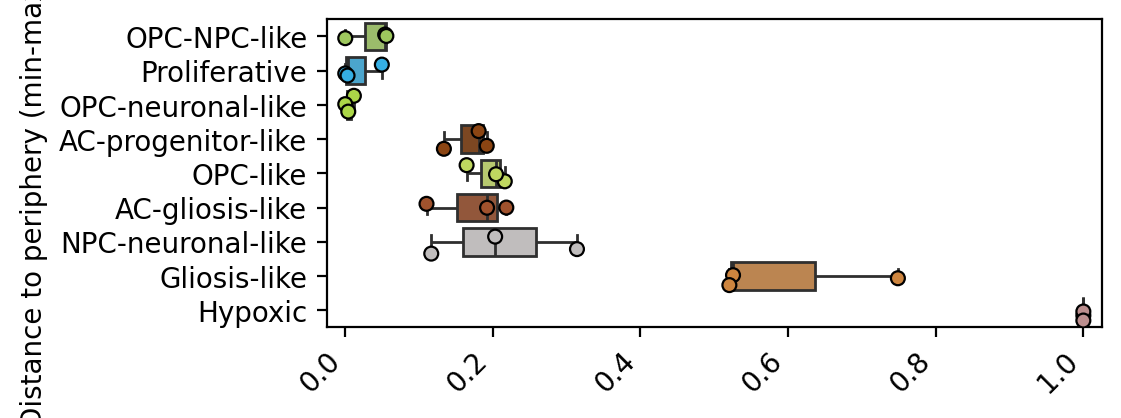

In [ ]:
line = 'E25'

plot_df = distance_df[distance_df['use_sample'].isnull()]\
    .groupby(['line', 'sample_name', 'ID', 'predictions'], 
                              as_index=False)['dist_to_edge'].mean()
plot_df = plot_df[plot_df['predictions'].isin(malignant_cts)]

ct_order = plot_df[(plot_df['line']==line)].groupby(['predictions'])['dist_to_edge'].median()\
    .sort_values(ascending=True).index

# process dist df
plot_df["distance_minmax"] = (
    plot_df["dist_to_edge"] - plot_df.groupby(['line', 
                                               'sample_name', 
                                               'ID',])["dist_to_edge"].transform("min")
) / (
    plot_df.groupby(['line', 'sample_name', 'ID'])["dist_to_edge"].transform("max")
    - plot_df.groupby(['line', 'sample_name', 'ID'])["dist_to_edge"].transform("min")
)

fig, ax = plt.subplots(figsize=(5,2))

plot_df["predictions"] = pd.Categorical(
    plot_df["predictions"],
    categories=ct_order,
    ordered=True,
)

sns.boxplot(data = plot_df[plot_df['line']==line], 
            y = 'predictions', x = 'distance_minmax', 
            palette = color_palette)
sns.stripplot(data=plot_df[plot_df['line']==line], 
              y='predictions', x='distance_minmax', color='black', 
              alpha=1, jitter=0.35, palette = color_palette, 
              edgecolor="black", linewidth=0.8)

plt.xticks(rotation=45, ha="right")
plt.ylabel('Distance to periphery (min-max µm)')
plt.xlabel('')
plt.xlim(-0.025,1.025)

plot_df.to_csv('../../../data/Fig5/Fig5e1_background.csv')

plt.savefig(os.path.join(dist_dir, '{}_ct_dists_background.pdf'.format(line)))

/tmp/ipykernel_3819090/3895552559.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = plot_df[plot_df['line']==line],
/tmp/ipykernel_3819090/3895552559.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df[plot_df['line']==line],


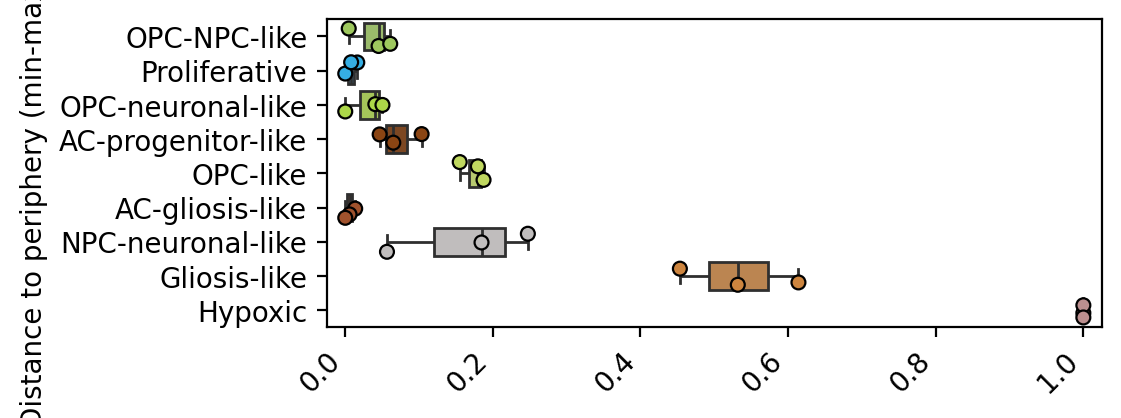

In [ ]:
line = 'E25'

plot_df = distance_df[~distance_df['use_sample'].isnull()]\
    .groupby(['line', 'sample_name', 'ID', 'predictions'], 
                              as_index=False)['dist_to_edge'].mean()
plot_df = plot_df[plot_df['predictions'].isin(malignant_cts)]

# process dist df
plot_df["distance_minmax"] = (
    plot_df["dist_to_edge"] - plot_df.groupby(['line', 
                                               'sample_name', 
                                               'ID',])["dist_to_edge"].transform("min")
) / (
    plot_df.groupby(['line', 'sample_name', 'ID'])["dist_to_edge"].transform("max")
    - plot_df.groupby(['line', 'sample_name', 'ID'])["dist_to_edge"].transform("min")
)

fig, ax = plt.subplots(figsize=(5,2))

plot_df["predictions"] = pd.Categorical(
    plot_df["predictions"],
    categories=ct_order,
    ordered=True,
)

sns.boxplot(data = plot_df[plot_df['line']==line], 
            y = 'predictions', x = 'distance_minmax', 
            palette = color_palette)
sns.stripplot(data=plot_df[plot_df['line']==line], 
              y='predictions', x='distance_minmax', color='black', 
              alpha=1, jitter=0.35, palette = color_palette, 
              edgecolor="black", linewidth=0.8)

plt.xticks(rotation=45, ha="right")
plt.ylabel('Distance to periphery (min-max µm)')
plt.xlabel('')
plt.xlim(-0.025,1.025)

plot_df.to_csv('../../../data/Fig5/Fig5e1_E25.csv')

plt.savefig(os.path.join(dist_dir, '{}_ct_dists.pdf'.format(line)))

/tmp/ipykernel_3819090/278929131.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = plot_df[plot_df['line']==line],
/tmp/ipykernel_3819090/278929131.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df[plot_df['line']==line],


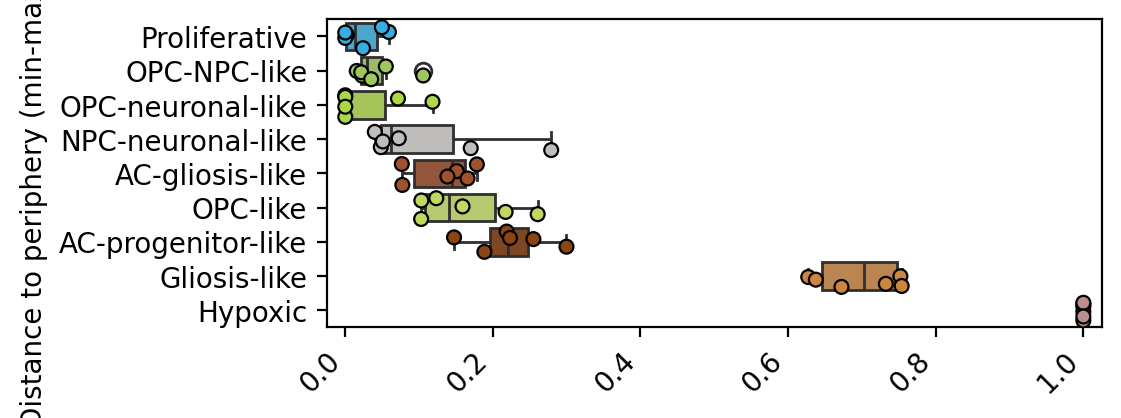

In [ ]:
line = 'E30'

plot_df = distance_df[distance_df['use_sample'].isnull()]\
    .groupby(['line', 'sample_name', 'ID', 'predictions'], 
                              as_index=False)['dist_to_edge'].mean()
plot_df = plot_df[plot_df['predictions'].isin(malignant_cts)]

ct_order = plot_df[(plot_df['line']==line)].groupby(['predictions'])['dist_to_edge'].median()\
    .sort_values(ascending=True).index

# process dist df
plot_df["distance_minmax"] = (
    plot_df["dist_to_edge"] - plot_df.groupby(['line', 
                                               'sample_name', 
                                               'ID',])["dist_to_edge"].transform("min")
) / (
    plot_df.groupby(['line', 'sample_name', 'ID'])["dist_to_edge"].transform("max")
    - plot_df.groupby(['line', 'sample_name', 'ID'])["dist_to_edge"].transform("min")
)

fig, ax = plt.subplots(figsize=(5,2))

plot_df["predictions"] = pd.Categorical(
    plot_df["predictions"],
    categories=ct_order,
    ordered=True,
)

sns.boxplot(data = plot_df[plot_df['line']==line], 
            y = 'predictions', x = 'distance_minmax', 
            palette = color_palette)
sns.stripplot(data=plot_df[plot_df['line']==line], 
              y='predictions', x='distance_minmax', color='black', 
              alpha=1, jitter=0.35, palette = color_palette, 
              edgecolor="black", linewidth=0.8)

plt.xticks(rotation=45, ha="right")
plt.ylabel('Distance to periphery (min-max µm)')
plt.xlabel('')
plt.xlim(-0.025,1.025)


plt.savefig(os.path.join(dist_dir, '{}_ct_dists_background.pdf'.format(line)))

/tmp/ipykernel_3819090/4144341430.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = plot_df[plot_df['line']==line],
/tmp/ipykernel_3819090/4144341430.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df[plot_df['line']==line],


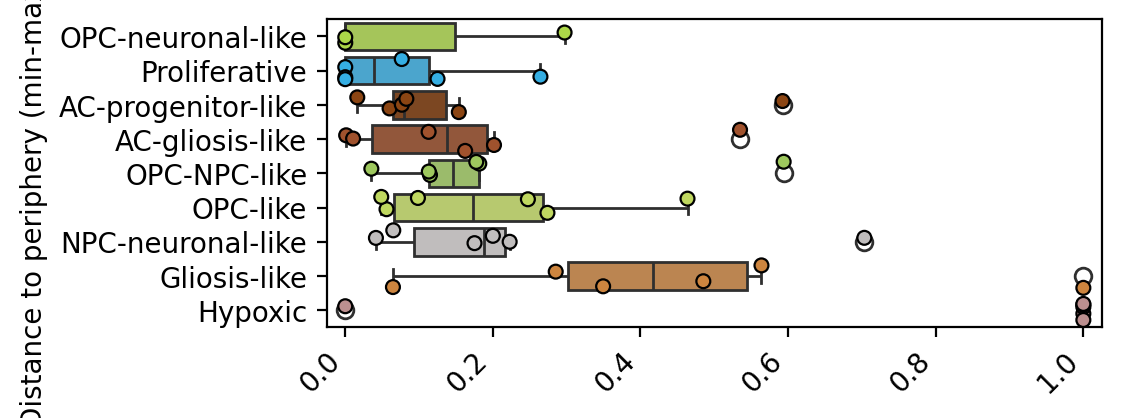

In [ ]:
line = 'E30'

plot_df = distance_df[~distance_df['use_sample'].isnull()]\
    .groupby(['line', 'sample_name', 'ID', 'predictions'], 
                              as_index=False)['dist_to_edge'].mean()
plot_df = plot_df[plot_df['predictions'].isin(malignant_cts)]

# process dist df
plot_df["distance_minmax"] = (
    plot_df["dist_to_edge"] - plot_df.groupby(['line', 
                                               'sample_name', 
                                               'ID',])["dist_to_edge"].transform("min")
) / (
    plot_df.groupby(['line', 'sample_name', 'ID'])["dist_to_edge"].transform("max")
    - plot_df.groupby(['line', 'sample_name', 'ID'])["dist_to_edge"].transform("min")
)

ct_order = plot_df[(plot_df['line']==line)].groupby(['predictions'])['distance_minmax'].median()\
    .sort_values(ascending=True).index


fig, ax = plt.subplots(figsize=(5,2))

plot_df["predictions"] = pd.Categorical(
    plot_df["predictions"],
    categories=ct_order,
    ordered=True,
)

sns.boxplot(data = plot_df[plot_df['line']==line], 
            y = 'predictions', x = 'distance_minmax', 
            palette = color_palette)
sns.stripplot(data=plot_df[plot_df['line']==line], 
              y='predictions', x='distance_minmax', color='black', 
              alpha=1, jitter=0.35, palette = color_palette, 
              edgecolor="black", linewidth=0.8)

plt.xticks(rotation=45, ha="right")
plt.ylabel('Distance to periphery (min-max µm)')
plt.xlabel('')
plt.xlim(-0.025,1.025)


plt.savefig(os.path.join(dist_dir, '{}_ct_dists.pdf'.format(line)))

# Gene expression over time

In [ ]:
genes = [
    "OLIG1",
    "SOX6",
    "PDGFRA",
    "DSCAM",
    "GRIA4",
    "GRIK2",
    "DLL3",
    "MYT1L",
    "DCX",
    "SOX11",
    "STMN2",
    "RYR3",
    "GFAP",
    "AQP4",
    "SLC1A3",
    "CD44",
    "ANXA3",
    "SERPINE1",
    "VIM",
    "VEGFA",
    "HILPDA",
    "MKI67",
    "CENPF"
]

/tmp/ipykernel_3819090/3252722881.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gene_df = dist_trimmed.groupby(['bin_center'], as_index=True)[genes].mean()


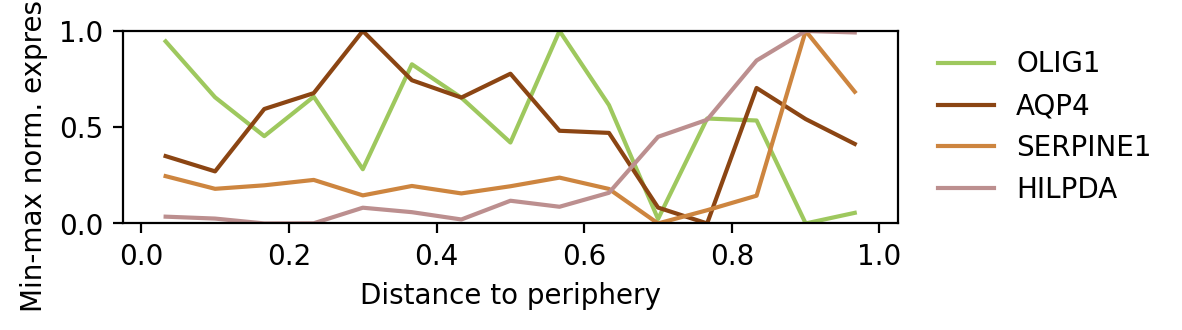

In [ ]:
line = 'E30'

dist_trimmed = distance_df[(distance_df['line']==line) &
                            ~(distance_df['use_sample'].isnull())]\
    [['cell_id', 'batch', 'dist_to_edge']]
dist_trimmed = dist_trimmed.rename(columns={'cell_id':'index'})

exp_df = pd.read_csv(os.path.join(dist_dir, 'selected_gene_expression.csv'), index_col=0)
exp_df['index'] = [re.sub('#.*$', '', i) for i in exp_df.index]
exp_df['batch'] = [re.sub('^.*#', '', i) for i in exp_df.index]

dist_trimmed = dist_trimmed.merge(exp_df, on = ['batch', 'index'])

# process dist df
dist_trimmed["distance_minmax"] = (
    dist_trimmed["dist_to_edge"] - dist_trimmed.groupby("batch")["dist_to_edge"].transform("min")
) / (
    dist_trimmed.groupby("batch")["dist_to_edge"].transform("max")
    - dist_trimmed.groupby("batch")["dist_to_edge"].transform("min")
)

dist_trimmed["dist_bin"] = pd.cut(dist_trimmed["distance_minmax"], bins=15)
dist_trimmed["bin_center"] = dist_trimmed["dist_bin"].apply(lambda x: x.mid)

# get mean per bin
gene_df = dist_trimmed.groupby(['bin_center'], as_index=True)[genes].mean()

# get min-max
mins = gene_df.min()
ranges = gene_df.max() - mins
gene_df = (gene_df - mins) / ranges

# for plot
gene_df = gene_df.reset_index().melt(id_vars='bin_center')

# tie color to order
genes_to_plot = ['OLIG1', 'AQP4', 'SERPINE1', 'HILPDA']
gene_df = gene_df[gene_df['variable'].isin(genes_to_plot)]

fig, ax = plt.subplots(figsize=(5, 1.25))

sns.lineplot(
    data=gene_df,
    x="bin_center",
    y="value",
    hue="variable",
    marker="",
    orient='x',
    palette=['#9ec85e', '#8b4513', '#cd853f', '#bc8f8f']
)

plt.ylabel('Min-max norm. expression')
plt.xlabel('Distance to periphery')

leg = ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

leg.get_title().set_rotation(-90)
leg.get_title().set_va("center")
leg.get_title().set_ha("center")
plt.ylim(0,1)
plt.xlim(-0.025,1.025)

#plt.gca().invert_yaxis()

plt.savefig(os.path.join(dist_dir, '{}_gene_peaks.pdf'.format(line)))

/tmp/ipykernel_3819090/199835451.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gene_df = dist_trimmed.groupby(['bin_center'], as_index=True)[genes].mean()


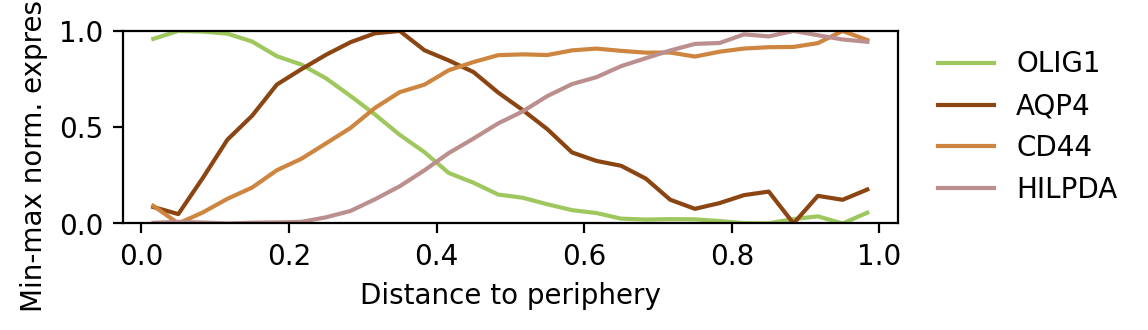

In [ ]:
line = 'E30'

dist_trimmed = distance_df[(distance_df['line']==line) &
                            (distance_df['use_sample'].isnull())]\
    [['cell_id', 'batch', 'dist_to_edge']]
dist_trimmed = dist_trimmed.rename(columns={'cell_id':'index'})
#dist_trimmed["batch"] = dist_trimmed["batch"].astype(str).str.replace(r"^.*/", "", regex=True)

exp_df = pd.read_csv(os.path.join(dist_dir, 'selected_gene_expression.csv'), index_col=0)
exp_df['index'] = [re.sub('#.*$', '', i) for i in exp_df.index]
exp_df['batch'] = [re.sub('^.*#', '', i) for i in exp_df.index]

dist_trimmed = dist_trimmed.merge(exp_df, on = ['batch', 'index'])

# process dist df
dist_trimmed["distance_minmax"] = (
    dist_trimmed["dist_to_edge"] - dist_trimmed.groupby("batch")["dist_to_edge"].transform("min")
) / (
    dist_trimmed.groupby("batch")["dist_to_edge"].transform("max")
    - dist_trimmed.groupby("batch")["dist_to_edge"].transform("min")
)

dist_trimmed["dist_bin"] = pd.cut(dist_trimmed["distance_minmax"], bins=30)
dist_trimmed["bin_center"] = dist_trimmed["dist_bin"].apply(lambda x: x.mid)

# get mean per bin
gene_df = dist_trimmed.groupby(['bin_center'], as_index=True)[genes].mean()

# get min-max
mins = gene_df.min()
ranges = gene_df.max() - mins
gene_df = (gene_df - mins) / ranges

# for plot
gene_df = gene_df.reset_index().melt(id_vars='bin_center')

# tie color to order
genes_to_plot = ['OLIG1', 'AQP4', 'CD44', 'HILPDA']
gene_df = gene_df[gene_df['variable'].isin(genes_to_plot)]

fig, ax = plt.subplots(figsize=(5, 1.25))

sns.lineplot(
    data=gene_df,
    x="bin_center",
    y="value",
    hue="variable",
    marker="",
    orient='x',
    palette=['#9ec85e', '#8b4513', '#cd853f', '#bc8f8f']
)

plt.ylabel('Min-max norm. expression')
plt.xlabel('Distance to periphery')

leg = ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

leg.get_title().set_rotation(-90)
leg.get_title().set_va("center")
leg.get_title().set_ha("center")
plt.ylim(0,1)
plt.xlim(-0.025,1.025)

#plt.gca().invert_yaxis()

plt.savefig(os.path.join(dist_dir, '{}_gene_peaks_background.pdf'.format(line)))

/tmp/ipykernel_3819090/2901628965.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gene_df = dist_trimmed.groupby(['bin_center'], as_index=True)[genes].mean()


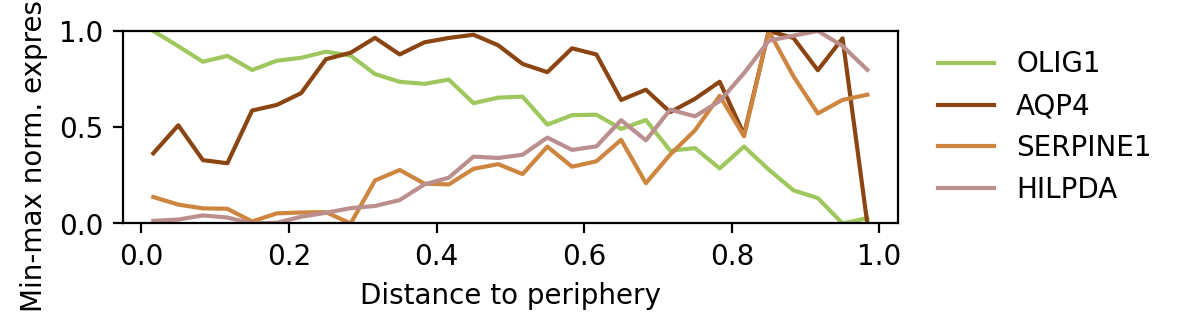

In [ ]:
line = 'E25'

dist_trimmed = distance_df[(distance_df['line']==line) &
                            ~(distance_df['use_sample'].isnull())]\
    [['cell_id', 'batch', 'dist_to_edge']]
dist_trimmed = dist_trimmed.rename(columns={'cell_id':'index'})
#dist_trimmed["batch"] = dist_trimmed["batch"].astype(str).str.replace(r"^.*/", "", regex=True)

exp_df = pd.read_csv(os.path.join(dist_dir, 'selected_gene_expression.csv'), index_col=0)
exp_df['index'] = [re.sub('#.*$', '', i) for i in exp_df.index]
exp_df['batch'] = [re.sub('^.*#', '', i) for i in exp_df.index]

dist_trimmed = dist_trimmed.merge(exp_df, on = ['batch', 'index'])

# process dist df
dist_trimmed["distance_minmax"] = (
    dist_trimmed["dist_to_edge"] - dist_trimmed.groupby("batch")["dist_to_edge"].transform("min")
) / (
    dist_trimmed.groupby("batch")["dist_to_edge"].transform("max")
    - dist_trimmed.groupby("batch")["dist_to_edge"].transform("min")
)

dist_trimmed["dist_bin"] = pd.cut(dist_trimmed["distance_minmax"], bins=30)
dist_trimmed["bin_center"] = dist_trimmed["dist_bin"].apply(lambda x: x.mid)

# get mean per bin
gene_df = dist_trimmed.groupby(['bin_center'], as_index=True)[genes].mean()

# get min-max
mins = gene_df.min()
ranges = gene_df.max() - mins
gene_df = (gene_df - mins) / ranges

# for plot
gene_df = gene_df.reset_index().melt(id_vars='bin_center')

# tie color to order
genes_to_plot = ['OLIG1', 'AQP4', 'SERPINE1', 'HILPDA']
gene_df = gene_df[gene_df['variable'].isin(genes_to_plot)]

fig, ax = plt.subplots(figsize=(5, 1.25))

sns.lineplot(
    data=gene_df,
    x="bin_center",
    y="value",
    hue="variable",
    marker="",
    orient='x',
    palette=['#9ec85e', '#8b4513', '#cd853f', '#bc8f8f']
)

plt.ylabel('Min-max norm. expression')
plt.xlabel('Distance to periphery')

leg = ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

leg.get_title().set_rotation(-90)
leg.get_title().set_va("center")
leg.get_title().set_ha("center")
plt.ylim(0,1)
plt.xlim(-0.025,1.025)

#plt.gca().invert_yaxis()
gene_df.to_csv('../../../data/Fig5/Fig5e2_E25.csv')

plt.savefig(os.path.join(dist_dir, '{}_gene_peaks.pdf'.format(line)))

/tmp/ipykernel_3819090/4181568580.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gene_df = dist_trimmed.groupby(['bin_center'], as_index=True)[genes].mean()


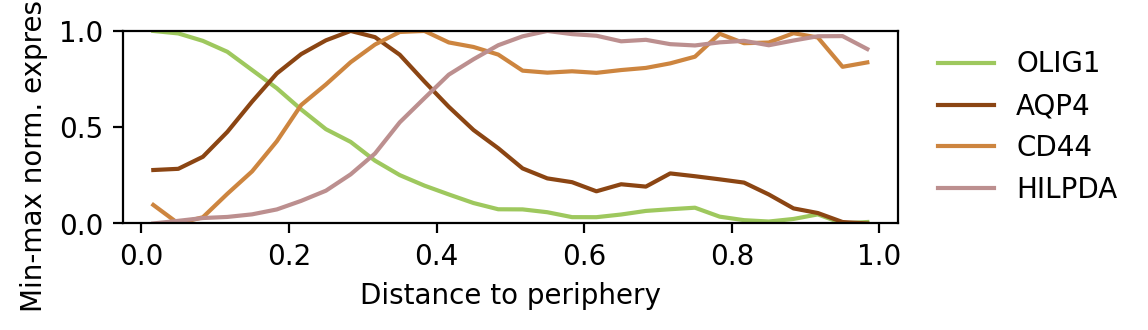

In [ ]:
line = 'E25'

dist_trimmed = distance_df[(distance_df['line']==line) &
                            (distance_df['use_sample'].isnull())]\
    [['cell_id', 'batch', 'dist_to_edge']]
dist_trimmed = dist_trimmed.rename(columns={'cell_id':'index'})
#dist_trimmed["batch"] = dist_trimmed["batch"].astype(str).str.replace(r"^.*/", "", regex=True)

exp_df = pd.read_csv(os.path.join(dist_dir, 'selected_gene_expression.csv'), index_col=0)
exp_df['index'] = [re.sub('#.*$', '', i) for i in exp_df.index]
exp_df['batch'] = [re.sub('^.*#', '', i) for i in exp_df.index]

dist_trimmed = dist_trimmed.merge(exp_df, on = ['batch', 'index'])

# process dist df
dist_trimmed["distance_minmax"] = (
    dist_trimmed["dist_to_edge"] - dist_trimmed.groupby("batch")["dist_to_edge"].transform("min")
) / (
    dist_trimmed.groupby("batch")["dist_to_edge"].transform("max")
    - dist_trimmed.groupby("batch")["dist_to_edge"].transform("min")
)

dist_trimmed["dist_bin"] = pd.cut(dist_trimmed["distance_minmax"], bins=30)
dist_trimmed["bin_center"] = dist_trimmed["dist_bin"].apply(lambda x: x.mid)

# get mean per bin
gene_df = dist_trimmed.groupby(['bin_center'], as_index=True)[genes].mean()

# get min-max
mins = gene_df.min()
ranges = gene_df.max() - mins
gene_df = (gene_df - mins) / ranges

# for plot
gene_df = gene_df.reset_index().melt(id_vars='bin_center')

# tie color to order
genes_to_plot = ['OLIG1', 'AQP4', 'CD44', 'HILPDA']
gene_df = gene_df[gene_df['variable'].isin(genes_to_plot)]

fig, ax = plt.subplots(figsize=(5, 1.25))

sns.lineplot(
    data=gene_df,
    x="bin_center",
    y="value",
    hue="variable",
    marker="",
    orient='x',
    palette=['#9ec85e', '#8b4513', '#cd853f', '#bc8f8f']
)

plt.ylabel('Min-max norm. expression')
plt.xlabel('Distance to periphery')

leg = ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

leg.get_title().set_rotation(-90)
leg.get_title().set_va("center")
leg.get_title().set_ha("center")
plt.ylim(0,1)
plt.xlim(-0.025,1.025)

#plt.gca().invert_yaxis()
gene_df.to_csv('../../../data/Fig5/Fig5e2_background.csv')

plt.savefig(os.path.join(dist_dir, '{}_gene_peaks_background.pdf'.format(line)))